# 04 - Multiclass e confronto dei segnali

Questo notebook aggiunge due analisi finali:

1. classificazione a 3 classi: `baseline`, `stress`, `amusement`;
2. confronto tra diverse combinazioni di segnali chest per il task binario.


## 1. Import delle librerie


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier


## 2. Caricamento delle feature


In [2]:
def find_features_path():
    candidates = [
        Path("/kaggle/working/data/processed/features_chest.csv"),
        Path("data/processed/features_chest.csv"),
        Path("../data/processed/features_chest.csv"),
        Path("/kaggle/input/datasets/itsvise/features-chest/features_chest.csv"),
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError("features_chest.csv non trovato. Eseguire prima il notebook 02-feature-extraction.ipynb.")


FEATURES_PATH = find_features_path()
features = pd.read_csv(FEATURES_PATH)

print("File caricato:", FEATURES_PATH)
print("Shape:", features.shape)
features.head()


File caricato: /kaggle/input/datasets/itsvise/features-chest/features_chest.csv
Shape: (526, 39)


,subject,start_idx,end_idx,start_seconds,end_seconds,label,label_name,binary_label,label_fraction,ECG_mean,...,Resp_min,Resp_max,Resp_range,Resp_median,Temp_mean,Temp_std,Temp_min,Temp_max,Temp_range,Temp_median
0,S2,210000,252000,300.0,360.0,1,baseline,non-stress,0.890881,0.001466,...,-5.550925,4.511106,10.062031,-0.086697,29.167694,0.060271,29.011780,29.426208,0.414429,29.158386
1,S2,252000,294000,360.0,420.0,1,baseline,non-stress,1.000000,0.000986,...,-1.391944,1.702889,3.094832,0.006293,28.885604,0.081293,28.727814,29.207275,0.479462,28.876862
2,S2,294000,336000,420.0,480.0,1,baseline,non-stress,1.000000,0.001455,...,-4.359904,2.069612,6.429516,0.048712,28.798114,0.037777,28.679108,28.988800,0.309692,28.793732
3,S2,336000,378000,480.0,540.0,1,baseline,non-stress,1.000000,0.001022,...,-1.527553,1.812610,3.340163,-0.008351,28.753808,0.063520,28.584656,29.023285,0.438629,28.736389
4,S2,378000,420000,540.0,600.0,1,baseline,non-stress,1.000000,0.001122,...,-1.513284,1.430502,2.943786,-0.005847,28.573873,0.041704,28.447449,28.820953,0.373505,28.561768


## 3. Colonne di feature


In [3]:
metadata_columns = {
    "subject",
    "start_idx",
    "end_idx",
    "start_seconds",
    "end_seconds",
    "label",
    "label_name",
    "binary_label",
    "label_fraction",
}

all_feature_columns = [col for col in features.columns if col not in metadata_columns]
groups = features["subject"]

print("Numero feature totali:", len(all_feature_columns))
print(all_feature_columns[:10])


Numero feature totali: 30
['ECG_mean', 'ECG_std', 'ECG_min', 'ECG_max', 'ECG_range', 'ECG_median', 'EDA_mean', 'EDA_std', 'EDA_min', 'EDA_max']


## 4. Funzione di valutazione leave-one-subject-out


In [4]:
def evaluate_logo(model, X, y, groups, average="binary"):
    logo = LeaveOneGroupOut()
    y_true_all = []
    y_pred_all = []

    for train_idx, test_idx in logo.split(X, y, groups):
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model),
        ])

        pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_pred = pipeline.predict(X.iloc[test_idx])

        y_true_all.extend(y.iloc[test_idx])
        y_pred_all.extend(y_pred)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    if average == "binary":
        return {
            "accuracy": accuracy_score(y_true_all, y_pred_all),
            "precision_stress": precision_score(y_true_all, y_pred_all, pos_label=1, zero_division=0),
            "recall_stress": recall_score(y_true_all, y_pred_all, pos_label=1, zero_division=0),
            "f1_stress": f1_score(y_true_all, y_pred_all, pos_label=1, zero_division=0),
        }

    return {
        "accuracy": accuracy_score(y_true_all, y_pred_all),
        "precision_macro": precision_score(y_true_all, y_pred_all, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true_all, y_pred_all, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true_all, y_pred_all, average="macro", zero_division=0),
    }


## 5. Task multiclass: baseline vs stress vs amusement


In [5]:
X_multi = features[all_feature_columns]
y_multi = features["label"]

multiclass_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    "kNN": KNeighborsClassifier(n_neighbors=5),
}

multiclass_results = []

for model_name, model in multiclass_models.items():
    print("Valuto", model_name)
    metrics = evaluate_logo(model, X_multi, y_multi, groups, average="macro")
    multiclass_results.append({"model": model_name, **metrics})

multiclass_results_df = pd.DataFrame(multiclass_results).sort_values("f1_macro", ascending=False)
multiclass_results_df


Valuto Logistic Regression
Valuto Decision Tree
Valuto Random Forest
Valuto kNN


,model,accuracy,precision_macro,recall_macro,f1_macro
2,Random Forest,0.735741,0.643298,0.610883,0.613920
0,Logistic Regression,0.631179,0.585174,0.603358,0.588010
1,Decision Tree,0.600760,0.568691,0.524299,0.533734
3,kNN,0.608365,0.552792,0.484075,0.499223


## 6. Confronto dei segnali per il task binario


In [6]:
def columns_for_signals(signals):
    selected = []
    for signal in signals:
        selected.extend([col for col in all_feature_columns if col.startswith(f"{signal}_")])
    return selected

signal_sets = {
    "solo EDA": ["EDA"],
    "EDA + ECG": ["EDA", "ECG"],
    "EDA + ECG + Resp": ["EDA", "ECG", "Resp"],
    "tutti i segnali chest": ["ECG", "EDA", "EMG", "Resp", "Temp"],
}

y_binary = (features["binary_label"] == "stress").astype(int)
base_model = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)

signal_results = []

for set_name, signals in signal_sets.items():
    selected_columns = columns_for_signals(signals)
    print("Valuto", set_name, "- feature:", len(selected_columns))
    metrics = evaluate_logo(base_model, features[selected_columns], y_binary, groups, average="binary")
    signal_results.append({
        "signal_set": set_name,
        "signals": ", ".join(signals),
        "n_features": len(selected_columns),
        **metrics,
    })

signal_results_df = pd.DataFrame(signal_results).sort_values("f1_stress", ascending=False)
signal_results_df


Valuto solo EDA - feature: 6
Valuto EDA + ECG - feature: 12
Valuto EDA + ECG + Resp - feature: 18
Valuto tutti i segnali chest - feature: 30


,signal_set,signals,n_features,accuracy,precision_stress,recall_stress,f1_stress
2,EDA + ECG + Resp,"EDA, ECG, Resp",18,0.880228,0.826389,0.757962,0.790698
3,tutti i segnali chest,"ECG, EDA, EMG, Resp, Temp",30,0.866920,0.878261,0.643312,0.742647
1,EDA + ECG,"EDA, ECG",12,0.830798,0.739437,0.668790,0.702341
0,solo EDA,EDA,6,0.777567,0.633333,0.605096,0.618893


## 7. Grafico del confronto tra segnali


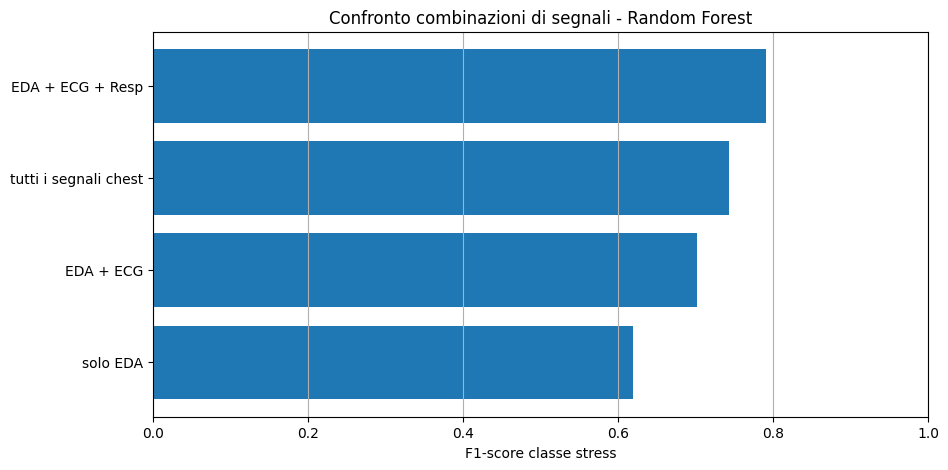

In [7]:
plot_df = signal_results_df.sort_values("f1_stress", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["signal_set"], plot_df["f1_stress"])
plt.xlabel("F1-score classe stress")
plt.title("Confronto combinazioni di segnali - Random Forest")
plt.xlim(0, 1)
plt.grid(axis="x")
plt.show()


## 8. Confronto con il paper WESAD

Il paper originale WESAD usa una pipeline piu' completa, con feature fisiologiche piu' specifiche e diversi classificatori classici.

Nel nostro progetto replichiamo una versione semplificata:

- stessi stati principali: baseline, stress, amusement;
- stesso obiettivo generale: riconoscimento dello stress;
- validazione corretta per soggetto;
- modelli classici e interpretabili;
- feature statistiche semplici su finestre temporali.

Differenze possibili rispetto al paper:

- feature meno sofisticate;
- filtraggio piu' semplice;
- uso iniziale dei soli segnali chest selezionati;
- finestre non sovrapposte per mantenere il progetto leggero;
- implementazione pensata per un progetto universitario replicabile.
